# $\nu_e$ CC Inclusive Selection (v2-2)

In [1]:
%matplotlib inline
 
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
 
CAFPYANA_WD  = "/home/castalyf/cafpyana"
ANALYSIS_DIR = "."
PLOT_DIR     = "./nuecc_plots"
DF_OUT_DIR   = "./nuecc_dfs"
MERGED_FILE  = "/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/merged.df"
TARGET_POT   = 6.6e20
TITLE        = r"SBND $\nu_e$ CC Inclusive"
 
os.makedirs(PLOT_DIR, exist_ok=True)
for p in [CAFPYANA_WD, CAFPYANA_WD + "/pyanalib", ANALYSIS_DIR]:
    if p not in sys.path:
        sys.path.insert(0, p)
 
import nue_helpers   as nh
import nue_selection as ns
 
%load_ext autoreload
%autoreload 2
print("All imports OK")

All imports OK


In [2]:
# SEL_TOPO_FILE = os.path.join(PLOT_DIR, "selected_nuecc_topo.df")
# SEL_QUAL_FILE = os.path.join(PLOT_DIR, "selected_nuecc_qual.df")
# sel_topo  = nh.load_selection(SEL_TOPO_FILE)
# sel_qual  = nh.load_selection(SEL_QUAL_FILE)
# truth_info = pd.read_hdf(MERGED_FILE, key="truth_info_0")
# pot_scale  = float(sel_topo["pot_scale"].iloc[0])

## 1. Check the keys in the sample

In [3]:
# import os
# import pandas as pd

# print("=== MC_FILE diagnostics ===")
# print(f"MC_FILE = {MC_FILE!r}")
# print(f"File exists?          {os.path.exists(MC_FILE)}")
# print(f"File size (bytes)     {os.path.getsize(MC_FILE) if os.path.exists(MC_FILE) else 'N/A'}")
# print(f"Is file?              {os.path.isfile(MC_FILE)}")

# try:
#     with pd.HDFStore(MC_FILE, mode='r') as store:
#         print(f"Available keys:       {store.keys()}")
#         print(f"Number of keys:       {len(store.keys())}")
# except Exception as e:
#     print(f"Error opening HDFStore: {e}")

## 2. Load the data frame

In [4]:
# ── Load merged file ─────────────────────────────────────────────
f = MERGED_FILE  # now a single file path

# ── Preselected particle-level df ────────────────────────────────
evtdf = pd.read_hdf(f, key="evt_0")

# ── Per-interaction truth metadata (ALL interactions, pre-cut) ───
truth_info = pd.read_hdf(f, key="truth_info_0")

print(f"\nevtdf      shape : {evtdf.shape}")
print(f"truth_info shape : {truth_info.shape}   (ALL interactions, pre-FM/FV)")
print(f"index names      : {evtdf.index.names}")
print(f"truth_info cols  : {list(truth_info.columns)}")

# ── truth_info category counts (pre-cut denominator) ─────────────
CAT_LABELS = {
    0: "nueCC FV (signal)",  1: "nueCC out FV",
    2: r"numuCC + π⁰",       3: r"NC π⁰",
    4: "other numuCC",       5: "other NC",
    6: "cosmic",             7: "other neutrino",
}

print("\nTruth categories (ALL interactions, pre-FM/FV):")
for c in range(8):
    n = (truth_info["truth_cat"] == c).sum()
    print(f"  cat {c}  {CAT_LABELS[c]:<22s}: {n:>9,}")

print(f"  {'total':<26s}: {len(truth_info):>9,}")


evtdf      shape : (13972305, 288)
truth_info shape : (57294092, 14)   (ALL interactions, pre-FM/FV)
index names      : ['__ntuple', 'entry', 'rec.dlp..index', 'rec.dlp.particles..index']
truth_info cols  : ['truth_cat', 'is_true_signal', 'is_nu', 'is_cc', 'is_fv_true', 'has_true_electron', 'has_true_muon', 'has_pi0', 'passed_fm', 'passed_fv_reco', 'passed_presel', 'true_leading_e_ke', 'true_leading_e_costheta', 'true_leading_e_p']

Truth categories (ALL interactions, pre-FM/FV):
  cat 0  nueCC FV (signal)     :    13,419
  cat 1  nueCC out FV          :     8,664
  cat 2  numuCC + π⁰           :   307,661
  cat 3  NC π⁰                 :   248,833
  cat 4  other numuCC          : 3,504,807
  cat 5  other NC              : 1,099,818
  cat 6  cosmic                : 50,841,454
  cat 7  other neutrino        : 1,269,436
  total                     : 57,294,092


In [5]:
with pd.HDFStore(MERGED_FILE, mode="r") as store:
    histpotdf = store["histpotdf_0"]
 
pot_col   = "pot" if "pot" in histpotdf.columns else histpotdf.select_dtypes("number").columns[0]
total_pot = float(histpotdf[pot_col].sum())
pot_scale = TARGET_POT / total_pot
 
print(f"Total POT    : {total_pot:.3e}")
print(f"Target POT   : {TARGET_POT:.3e}")
print(f"Scale factor : {pot_scale:.4f}")
 

Total POT    : 4.529e+20
Target POT   : 6.600e+20
Scale factor : 1.4574


In [6]:
# visualize the structure

cols = [" -> ".join([str(c) for c in col if c != ""]) for col in evtdf.columns]

# Determine the midpoint
mid = (len(cols) + 1) // 2
left = cols[:mid]
right = cols[mid:]

# Set a fixed width for alignment
width = max(len(c) for c in left) + 4

for l, r in zip(left, right + [""] * (len(left) - len(right))):
    print(f"{l:<{width}}{r}")

###############
# # save a few events into csv 

# subset = evtdf.reset_index().head(100)
# subset.to_csv("evtdf_preview.csv", index=False)
# print("Saved: evtdf_preview.csv")

# interaction_subset = (
#     evtdf
#     .xs((1, 0, 0), level=['__ntuple', 'entry', 'rec.dlp..index'])
#     .reset_index()
# )
# interaction_subset.to_csv("interaction01_preview.csv", index=False)
# print("Saved: interaction01_preview.csv")


# export_df = pd.concat([
#     evtdf["rec"]["dlp_true"]["particles"],
#     evtdf["rec"]["dlp"]["particles"]
# ], axis=1).reset_index()

# export_df.head(1000).to_csv("particle_preview.csv", index=False)
# print("Saved: particle_preview.csv")

rec -> dlp -> match_ids                             rec -> dlp -> particles -> mcs_ke_per_pid -> I3
rec -> dlp -> match_overlaps                        rec -> dlp -> particles -> mcs_ke_per_pid -> I4
rec -> dlp -> cathode_offset                        rec -> dlp -> particles -> mcs_ke_per_pid -> I5
rec -> dlp -> depositions_sum                       rec -> dlp -> particles -> momentum -> x
rec -> dlp -> flash_hypo_pe                         rec -> dlp -> particles -> momentum -> y
rec -> dlp -> flash_total_pe                        rec -> dlp -> particles -> momentum -> z
rec -> dlp -> id                                    rec -> dlp -> particles -> num_fragments
rec -> dlp -> is_cathode_crosser                    rec -> dlp -> particles -> p
rec -> dlp -> is_contained                          rec -> dlp -> particles -> pdg_code
rec -> dlp -> is_fiducial                           rec -> dlp -> particles -> pid
rec -> dlp -> is_flash_matched                      rec -> dlp -> particles 

## 3. True signal definition

In [7]:
# ALL counts below come from truth_info (covers pre-FM/FV universe).
# This is the ONLY correct denominator — never recount from evtdf (which has
# already dropped non-FM/FV events).
 
# ── Denominators from truth_info ─────────────────────────────────────────────
n_inter_total   = len(truth_info)
n_true_signal   = int(truth_info["is_true_signal"].sum())           # <- THE denominator
 
# FM stage (from truth_info)
ti_fm           = truth_info[truth_info["passed_fm"]]
n_inter_fm      = len(ti_fm)
n_sig_fm        = int(ti_fm["is_true_signal"].sum())
 
# FV stage (from truth_info — sequential: FM then FV)
ti_fv           = truth_info[truth_info["passed_presel"]]           # passed_presel = FM & FV
n_inter_fv      = len(ti_fv)
n_sig_fv        = int(ti_fv["is_true_signal"].sum())
 
print(f"True nueCC-in-FV signal (pre-cut)  : {n_true_signal:,}  <- efficiency denominator")
print(f"Interactions (pre-cut)             : {n_inter_total:,}")
print(f"After FM   : {n_inter_fm:,} inter  {n_sig_fm:,} signal")
print(f"After FM+FV: {n_inter_fv:,} inter  {n_sig_fv:,} signal")
 
# ── Alignment helpers for later cells ────────────────────────────────────────
il              = nh.inter_levels(evtdf)
presel_inter    = evtdf.groupby(level=il).size().index          # interactions in evt_0
truth_cat_presel = truth_info["truth_cat"].reindex(presel_inter) # cat for preselected inters
 
# sig_inter_idx: signal interactions visible in evtdf (survived FM+FV)
# Used for purity at the topology stage
sig_inter_idx   = truth_info.index[
    truth_info["is_true_signal"] & truth_info.index.isin(presel_inter)
]
sig_mask_presel = presel_inter.isin(sig_inter_idx)   # bool, aligned to presel_inter
 
# ── Convenience wrappers ─────────────────────────────────────────────────────
rp      = nh.reco_particles(evtdf)
tp      = nh.true_particles(evtdf)
ri      = nh.reco_interactions(evtdf)
ti_view = nh.true_interactions(evtdf)
 
print("\nrp.pid.value_counts():\n", rp.pid.value_counts().head())

True nueCC-in-FV signal (pre-cut)  : 13,419  <- efficiency denominator
Interactions (pre-cut)             : 57,294,092
After FM   : 5,129,043 inter  11,609 signal
After FM+FV: 2,943,724 inter  11,492 signal

rp.pid.value_counts():
 pid
4    4406108
1    3056795
2    2822102
0    2798793
3     888507
Name: count, dtype: int64


In [8]:
# # ── Truth classification (runs on skimmed df — same code, fewer rows) ───────
# truth_cat = ns.classify_truth(evtdf, verbose=True)

# # ── Signal denominator: use the pre-counted JSON value ──────────────────────
# # Do NOT recount from evtdf — skimmed df dropped some pre-FM/FV events,
# # so true_signal_index(evtdf) would undercount signal that didn't pass FM/FV
# # but IS part of the true denominator.
# n_true_signal_total = _denom["n_true_signal"]   # counted before any cut
# print(f"\nTrue nueCC-in-FV signal (all files, pre-cut): {n_true_signal_total:,}")

# # sig_inter_idx is still useful for purity/efficiency alignment within
# # the skimmed df (events that survived FM+FV and are signal):
# sig_inter_idx = ns.true_signal_index(evtdf)
# print(f"True signal visible in skimmed df          : {len(sig_inter_idx):,}")

## 4. Selection 

In [8]:
#  "No cut" row  = 100% by definition (pre-cut universe)
#  FM / FV rows  = from truth_info (pre-cut flags) -- NO re-application to evtdf
#  Topology row  = from build_cut_flow applied to preselected evtdf
# -----------------------------------------------------------------------------
cut_flow = ns.build_cut_flow(evtdf)   # starts from presel'd evtdf (FM+FV already done)
 
# ── Topology stage: single_electron ──────────────────────────────────────────
se_idx        = cut_flow["single_electron"]["inter_index"]
n_inter_se    = len(se_idx)
# signal at topology stage: signal interactions that survived FM+FV AND topology
n_sig_se      = int(truth_info.loc[
    truth_info["is_true_signal"] & truth_info.index.isin(se_idx), "is_true_signal"
].sum())
 
# purity helpers (all relative to preselected interactions)
def _purity(stage_idx):
    n_sel_no7 = int((truth_info["truth_cat"].reindex(stage_idx).fillna(7) != 7).sum())
    if n_sel_no7 == 0:
        return float("nan")
    n_sig = int(truth_info.loc[
        truth_info["is_true_signal"] & truth_info.index.isin(stage_idx),
        "is_true_signal",
    ].sum())
    return n_sig / n_sel_no7
 
pur_fm = n_sig_fm  / n_inter_fm  if n_inter_fm  > 0 else float("nan")
pur_fv = n_sig_fv  / n_inter_fv  if n_inter_fv  > 0 else float("nan")
pur_se = _purity(se_idx)
eff_fm = n_sig_fm  / n_true_signal if n_true_signal > 0 else float("nan")
eff_fv = n_sig_fv  / n_true_signal if n_true_signal > 0 else float("nan")
eff_se = n_sig_se  / n_true_signal if n_true_signal > 0 else float("nan")
 
W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_inter_fm:>9,}  {pur_fm*100:>7.1f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_inter_fv:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_inter_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]


Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)         57,294,092         —        100.0%
  Flash match                5,129,043      0.2%         86.5%
  In FV                      2,943,724      0.4%         85.6%
  Final state topology          81,970     15.3%         81.2%


### 4-1. Efficiency/purity stats

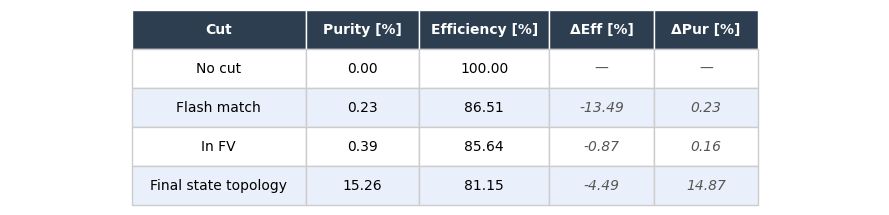

In [10]:
CUT_DISPLAY = ["No cut", "Flash match", "In FV", "Final state topology"]
purs_table  = [0.0,   pur_fm, pur_fv, pur_se]
effs_table  = [1.0,   eff_fm, eff_fv, eff_se]

fig_tbl, ax_tbl = plt.subplots(figsize=(9, 2.6))
nh.create_purity_efficiency_table(purs_table, effs_table, CUT_DISPLAY, ax_tbl)
fig_tbl.tight_layout()
plt.show()
nh.save_plot("pur_eff_table", fig=fig_tbl, folder_name=PLOT_DIR)

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 38,467
Raw min  : 9.4945
Raw max  : 33956.8484
Raw mean : 574.6633
Raw median: 330.4856
After *1000 (GeV→MeV)  → min/max: 9494.5 – 33956848.4 MeV
After *1     (already MeV) → min/max: 9.5 – 33956.8 MeV


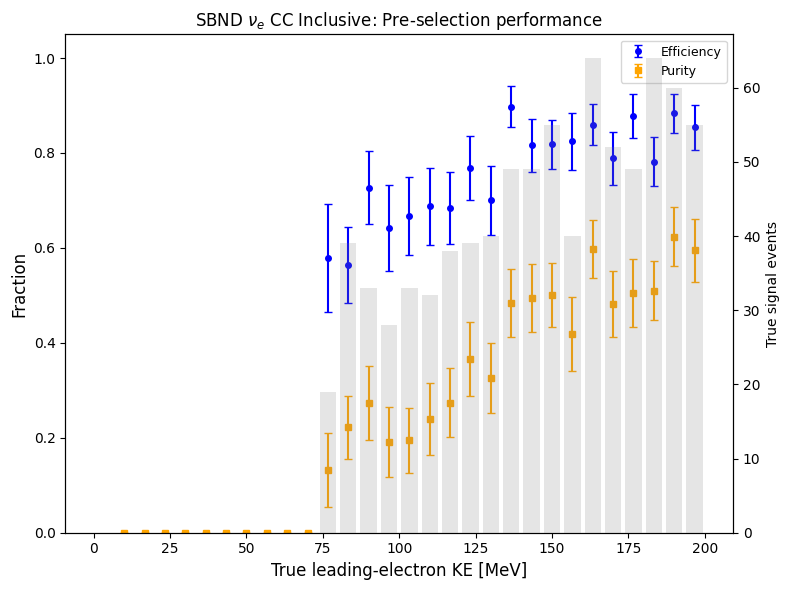

In [11]:
true_ke_all       = ns.true_leading_electron_ke(evtdf)
true_costheta_all = ns.true_leading_electron_costheta(evtdf)
true_ke_aligned = true_ke_all.reindex(presel_inter)
true_ct_aligned = true_costheta_all.reindex(presel_inter)

ke_bins    = np.linspace(0, 200, 31)

stage_idx  = cut_flow["single_electron"]["inter_index"]
stage_mask = presel_inter.isin(stage_idx)

# cat-7-free selection mask (efficiency numerator unaffected since signal ≠ cat 7)
nocat7_mask = (truth_cat_presel != 7).reindex(presel_inter).fillna(True).values

centers, purs_b, effs_b, counts_b = nh.pur_eff_binned(
    values   = true_ke_aligned.fillna(-999).values,
    bins     = ke_bins,
    sel_mask = stage_mask & nocat7_mask,   # ← exclude cat 7 from purity denom
    sig_mask = sig_mask_presel,
)

# binomial errors: √(p(1−p)/n), guard against n=0
n        = np.maximum(counts_b, 1)
eff_err  = np.sqrt(effs_b * (1 - effs_b) / n)
pur_err  = np.sqrt(purs_b * (1 - purs_b) / n)

fig_bin, ax_bin = plt.subplots(figsize=(8, 6))
ax2 = ax_bin.twinx()

ax_bin.errorbar(centers, effs_b, yerr=eff_err,
                fmt="o", color="blue",   capsize=3, ms=4, label="Efficiency")
ax_bin.errorbar(centers, purs_b, yerr=pur_err,
                fmt="s", color="orange", capsize=3, ms=4, label="Purity")
ax_bin.set_ylim(0, 1.05)
ax_bin.set_xlabel("True leading-electron KE [MeV]", fontsize=12)
ax_bin.set_ylabel("Fraction", fontsize=12)
ax_bin.set_title(fr"{TITLE}: Pre-selection performance")
ax_bin.legend(fontsize=9)

ax2.bar(centers, counts_b,
        width=np.diff(centers).mean() * 0.8,
        alpha=0.2, color="gray", label="True signal")
ax2.set_ylabel("True signal events", fontsize=10)

plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_pur_ke", fig=fig_bin, folder_name=PLOT_DIR)

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:560: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  mask        = true_series.index.isin(stage_idx)


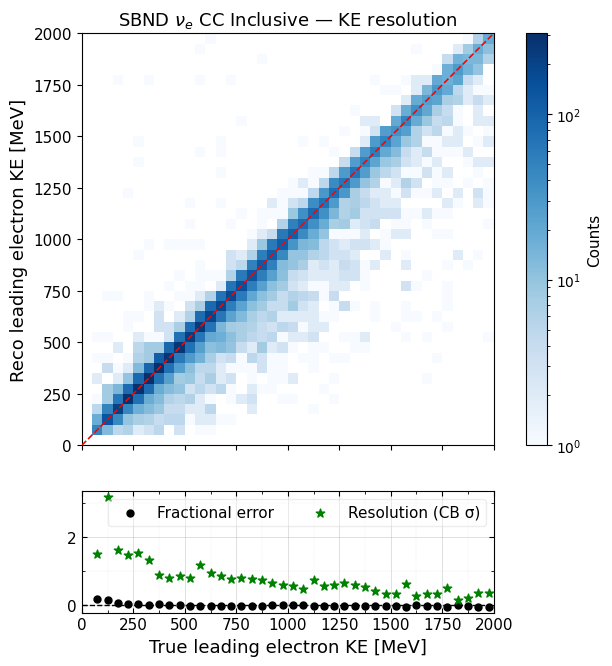

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:971: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:560: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  mask        = true_series.index.isin(stage_idx)


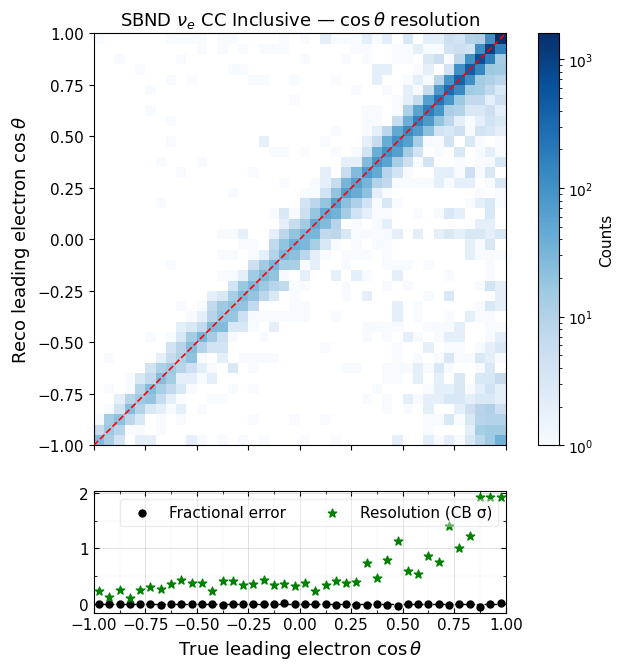

/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:971: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


In [20]:
# ── Resolution plots: true vs reco for leading electron ──────────────────────
#
# True quantities come from truth_info (already computed above as
# true_ke_aligned / true_ct_aligned).  Reco quantities are derived
# here from reco_particles, matching the pattern in threshold_plots.

# ── Build reco leading-electron series ───────────────────────────────────────
rp_df   = rp._df
ke_col  = ('ke',  '') if ('ke',  '') in rp_df.columns else 'ke'
pid_col = ('pid', '') if ('pid', '') in rp_df.columns else 'pid'

# electrons only
ele_df  = rp_df[rp_df[pid_col] == nh.PID_ELECTRON]

# leading = highest-KE electron per interaction
_il     = nh.inter_levels(evtdf)
_lead_i = ele_df[ke_col].groupby(level=_il).idxmax().dropna()

reco_ke_leading = (
    ele_df.loc[_lead_i, ke_col]
    .copy()
    .droplevel(-1)          # drop particle index, keep interaction index
)

# costheta: derive from direction vector of the same leading electron
# adjust column names to match your SPINE output (check rp_df.columns)
dir_cols = {ax: (f'start_dir', ax) if ('start_dir', ax) in rp_df.columns
            else f'start_dir_{ax}' for ax in ('x', 'y', 'z')}

_lead_ele = ele_df.loc[_lead_i].copy()
_lead_ele.index = _lead_ele.index.droplevel(-1)

dx = _lead_ele[dir_cols['x']].astype(float)
dy = _lead_ele[dir_cols['y']].astype(float)
dz = _lead_ele[dir_cols['z']].astype(float)
_norm = np.sqrt(dx**2 + dy**2 + dz**2).replace(0, np.nan)

reco_costheta_leading = dz / _norm   # costheta w.r.t. beam (z) axis

# ── Align to presel_inter ─────────────────────────────────────────────────────
reco_ke_aligned = reco_ke_leading.reindex(presel_inter)
reco_ct_aligned = reco_costheta_leading.reindex(presel_inter)

# ── Choose stage (e.g. single_electron; pass None for FM+FV only) ────────────
stage_idx = cut_flow["single_electron"]["inter_index"]

sig_only = true_ke_aligned.index.isin(sig_inter_idx)

# ── KE resolution ─────────────────────────────────────────────────────────
fig_ke, _ = nh.plot_leading_e_resolution(
    # true_series = true_ke_aligned,
    # reco_series = reco_ke_aligned,
    true_series = true_ke_aligned[sig_only],
    reco_series = reco_ke_aligned[sig_only],
    bins        = ke_bins,
    stage_idx   = stage_idx,
    # stage_idx   = None,
    xlabel      = 'True leading electron KE [MeV]',   # (3)
    ylabel      = 'Reco leading electron KE [MeV]',   # (3)
    normalize   = True,
    log_color   = True,
    title       = fr"{TITLE} — KE resolution",
)
plt.show()
nh.save_plot("resolution_ke", fig=fig_ke, folder_name=PLOT_DIR)

sig_only = true_ct_aligned.index.isin(sig_inter_idx)

# ── cos θ resolution ───────────────────────────────────────────────────────
fig_ct, _ = nh.plot_leading_e_resolution(
    true_series = true_ct_aligned[sig_only],
    reco_series = reco_ct_aligned[sig_only],
    bins        = ct_bins,
    stage_idx   = stage_idx,
    xlabel      = r'True leading electron $\cos\theta$',   # (3)
    ylabel      = r'Reco leading electron $\cos\theta$',   # (3)
    normalize   = False,
    log_color   = True,
    title       = fr"{TITLE} — $\cos\theta$ resolution",
)
plt.show()
nh.save_plot("resolution_costheta", fig=fig_ct, folder_name=PLOT_DIR)

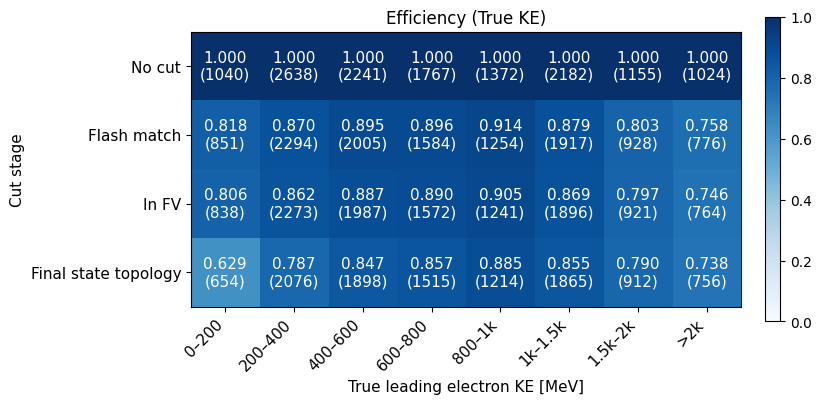

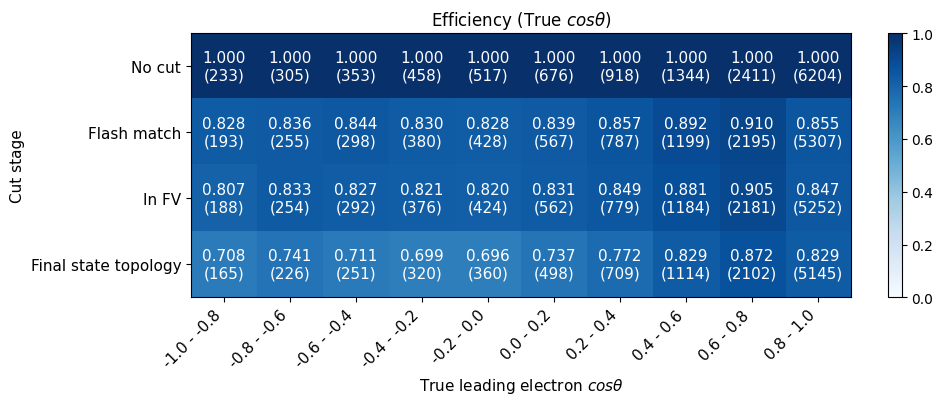

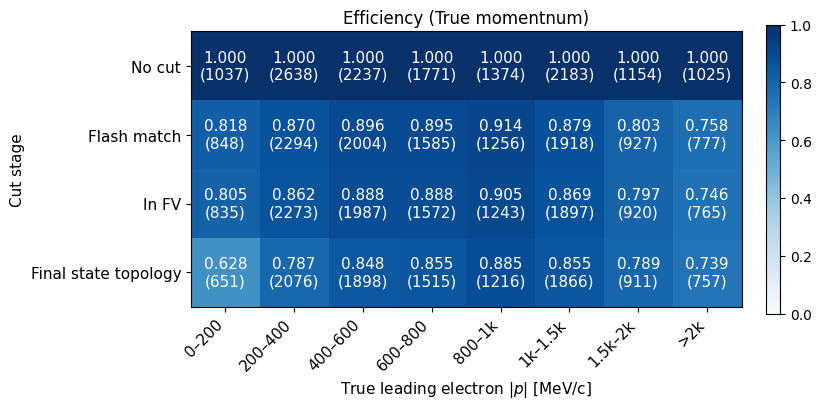

In [13]:
# ── Stage selection masks (aligned to truth_info index) ──────────────────────
stage_sel = {
    "precut"          : np.ones(len(truth_info), dtype=bool),
    "valid_flashmatch": truth_info["passed_fm"].values,
    "fiducial"        : truth_info["passed_presel"].values,
    "single_electron" : truth_info.index.isin(          # .isin() on Index → ndarray directly
                            cut_flow["single_electron"]["inter_index"]),
}
sig_true_vals = truth_info["is_true_signal"].values
n_cuts        = len(ns.CUT_NAMES)


# ── Efficiency matrix: true KE bins × cut stages ─────────────────────────────
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_ke_bins = len(ke_bins_c) - 1

ke_vals = truth_info["true_leading_e_ke"].fillna(-999).values

ke_eff_matrix   = np.zeros((n_ke_bins, n_cuts))
ke_count_matrix = np.zeros((n_ke_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals >= lo) & (ke_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        ke_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        ke_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    ke_eff_matrix, ke_count_matrix,
    bin_values       = np.arange(n_ke_bins),
    bin_labels       = ke_bin_labels,
    cut_labels       = ns.CUT_LABELS,
    remove_dummy_col = False,
    xlabel           = "True leading electron KE [MeV]",
    title            = "Efficiency (True KE)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke", fig=fig, folder_name=PLOT_DIR)


# ── Efficiency matrix: true cos θ bins × cut stages ──────────────────────────
ct_bins_c = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0,
                        0.2,  0.4,  0.6,  0.8,  1.0])
ct_bin_labels = [
    "-1.0 - -0.8", "-0.8 - -0.6", "-0.6 - -0.4", "-0.4 - -0.2", "-0.2 - 0.0",
    "0.0 - 0.2",   "0.2 - 0.4",   "0.4 - 0.6",   "0.6 - 0.8",   "0.8 - 1.0",
]
n_ct_bins = len(ct_bins_c) - 1

ct_vals = truth_info["true_leading_e_costheta"].fillna(-999).values

ct_eff_matrix   = np.zeros((n_ct_bins, n_cuts))
ct_count_matrix = np.zeros((n_ct_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(ct_bins_c[:-1], ct_bins_c[1:])):
        in_bin       = (ct_vals >= lo) & (ct_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        ct_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        ct_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    ct_eff_matrix, ct_count_matrix,
    bin_values       = np.arange(n_ct_bins),
    bin_labels       = ct_bin_labels,
    cut_labels       = ns.CUT_LABELS,
    remove_dummy_col = False,
    xlabel           = r"True leading electron $cos\theta$",
    title            = r"Efficiency (True $cos\theta$)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_costheta", fig=fig, folder_name=PLOT_DIR)


# ── Efficiency matrix: true |p| bins × cut stages ────────────────────────────
p_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
p_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_p_bins = len(p_bins_c) - 1

p_vals = truth_info["true_leading_e_p"].fillna(-999).values

p_eff_matrix   = np.zeros((n_p_bins, n_cuts))
p_count_matrix = np.zeros((n_p_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES):
    reco_sel = stage_sel[cut_name]
    for i, (lo, hi) in enumerate(zip(p_bins_c[:-1], p_bins_c[1:])):
        in_bin       = (p_vals >= lo) & (p_vals < hi)
        sig_total    = (in_bin & sig_true_vals).sum()
        sig_selected = (in_bin & sig_true_vals & reco_sel).sum()
        p_eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        p_count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    p_eff_matrix, p_count_matrix,
    bin_values       = np.arange(n_p_bins),
    bin_labels       = p_bin_labels,
    cut_labels       = ns.CUT_LABELS,
    remove_dummy_col = False,
    xlabel           = r"True leading electron $|p|$ [MeV/c]",
    title            = "Efficiency (True momentnum)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_p", fig=fig, folder_name=PLOT_DIR)

### 4-2. Histograms

=== RAW tp.ke VALUES (primary electrons) ===
Number of primary electrons : 38,467
Raw min  : 9.4945
Raw max  : 33956.8484
Raw mean : 574.6633
Raw median: 330.4856
After *1000 (GeV→MeV)  → min/max: 9494.5 – 33956848.4 MeV
After *1     (already MeV) → min/max: 9.5 – 33956.8 MeV


/home/castalyf/cafpyana/envs/venv_py310_cafpyana/lib/python3.10/site-packages/tables/attributeset.py:462: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_namerec.dlp..index'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)


Saved selection df → ./nuecc_plots/selected_nuecc_topo.df
  shape=(2943724, 11)  size=12.5 MB
sel_topo saved. evtdf still in memory for threshold scans.


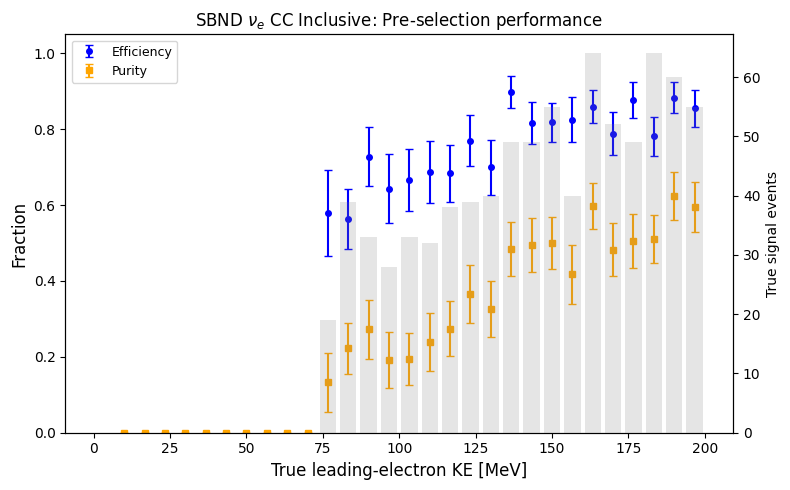

In [14]:
import gc

SEL_TOPO_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_topo.df")

_stage_idx_topo = {
    "precut"          : presel_inter,
    "valid_flashmatch": truth_info.index[truth_info["passed_fm"]],
    "fiducial"        : truth_info.index[truth_info["passed_presel"]],
    "single_electron" : cut_flow["single_electron"]["inter_index"],
}

sel_topo = nh.build_and_save_selection(
    path             = SEL_TOPO_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    true_ke          = ns.true_leading_electron_ke(evtdf),
    true_cos         = ns.true_leading_electron_costheta(evtdf),
    stage_idx_dict   = _stage_idx_topo,
    cut_names        = list(_stage_idx_topo.keys()),
    pot_scale        = pot_scale,
)
# evtdf kept alive — threshold scans still need it
print("sel_topo saved. evtdf still in memory for threshold scans.")

# ── Binned eff/pur from sel_topo ──────────────────────────────────────────────
ke_bins_eff = np.linspace(0, 200, 31)
nocat7      = (sel_topo["truth_cat"] != 7).values

centers, purs_b, effs_b, counts_b = nh.pur_eff_binned(
    values   = sel_topo["true_ke"].fillna(-999).values,
    bins     = ke_bins_eff,
    sel_mask = sel_topo["sel_single_electron"].values & nocat7,
    sig_mask = sel_topo["is_sig"].values,
)
n       = np.maximum(counts_b, 1)
eff_err = np.sqrt(effs_b * (1 - effs_b) / n)
pur_err = np.sqrt(purs_b * (1 - purs_b) / n)

fig_bin, ax_bin = plt.subplots(figsize=(8, 5))
ax2 = ax_bin.twinx()
ax_bin.errorbar(centers, effs_b, yerr=eff_err, fmt="o", color="blue",
                capsize=3, ms=4, label="Efficiency")
ax_bin.errorbar(centers, purs_b, yerr=pur_err, fmt="s", color="orange",
                capsize=3, ms=4, label="Purity")
ax_bin.set_ylim(0, 1.05)
ax_bin.set_xlabel("True leading-electron KE [MeV]", fontsize=12)
ax_bin.set_ylabel("Fraction", fontsize=12)
ax_bin.set_title(fr"{TITLE}: Pre-selection performance")
ax_bin.legend(fontsize=9)
ax2.bar(centers, counts_b, width=np.diff(centers).mean() * 0.8,
        alpha=0.2, color="gray")
ax2.set_ylabel("True signal events", fontsize=10)
plt.tight_layout()
plt.show()
nh.save_plot("binned_eff_pur_ke", fig=fig_bin, folder_name=PLOT_DIR)

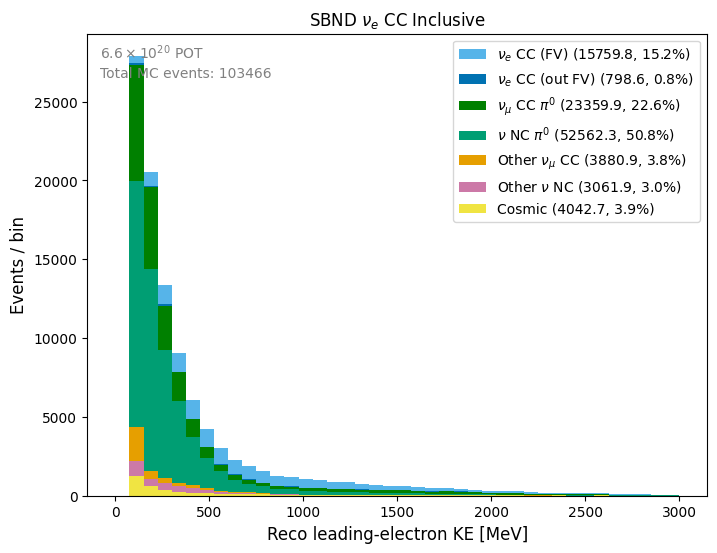

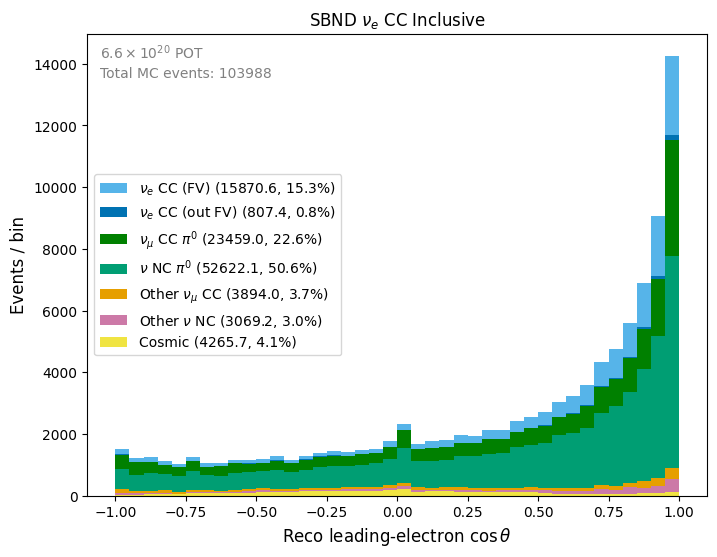

In [15]:
# ── Topology stacked histograms from sel_topo ─────────────────────────────────
DISPLAY_CATS = [0, 1, 2, 3, 4, 5, 6]

def _topo_cat(col, cat):
    mask = sel_topo["sel_single_electron"] & (sel_topo["truth_cat"] == cat)
    return sel_topo.loc[mask, col].dropna().values

_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS]
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS]

fig_ke, ax_ke = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 3000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke", fig=fig_ke, folder_name=PLOT_DIR)

fig_cos, ax_cos = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_topo_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE}", pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta", fig=fig_cos, folder_name=PLOT_DIR)

## 5. Shower quality cuts

In [11]:
import nue_helpers as nh
import nue_selection as ns

# truth_cat_presel already computed from truth_info in cell 4 — use directly
truth_cats = truth_cat_presel   # replaces: ns.classify_truth(evtdf, verbose=False)



/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1008: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/castalyf/cafpyana/analysis_village/nueCC/./nue_helpers.py:1190: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


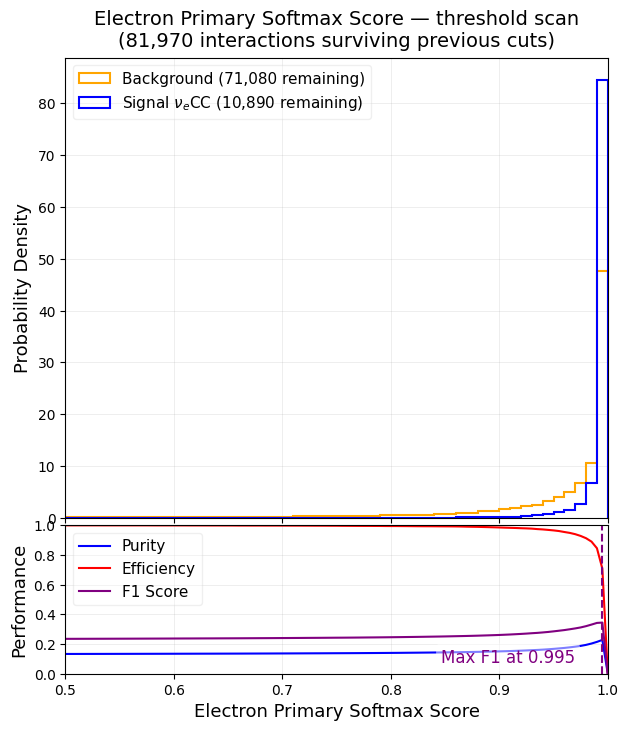


──────────────────────────────────────────────────
  Variable   : primary_scores
  Remaining  : 81,970 interactions (10890 signal, 71080 bkg)
  Cut dir    : > 0.9950
  Efficiency : 70.8%  (of remaining signal)
  Purity     : 22.8%
  Max F1     : 0.3446
──────────────────────────────────────────────────



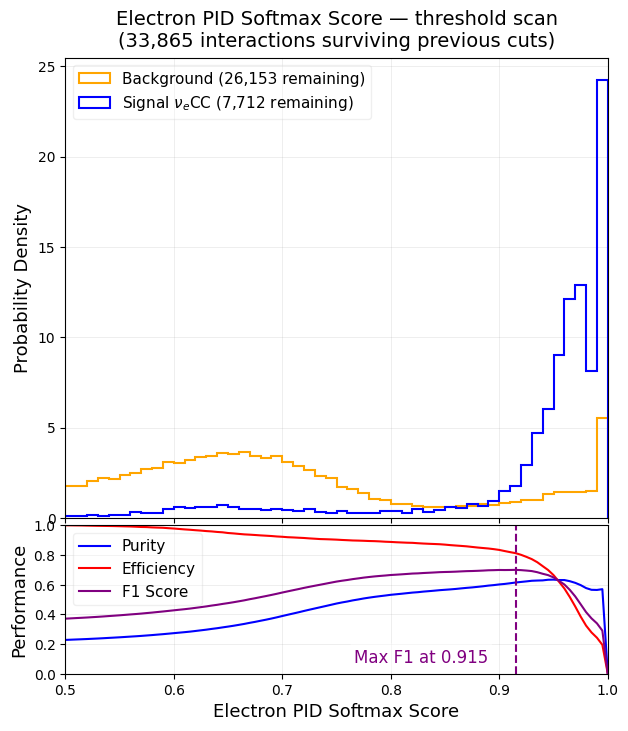


──────────────────────────────────────────────────
  Variable   : pid_scores
  Remaining  : 33,865 interactions (7712 signal, 26153 bkg)
  Cut dir    : > 0.9150
  Efficiency : 81.2%  (of remaining signal)
  Purity     : 61.4%
  Max F1     : 0.6996
──────────────────────────────────────────────────



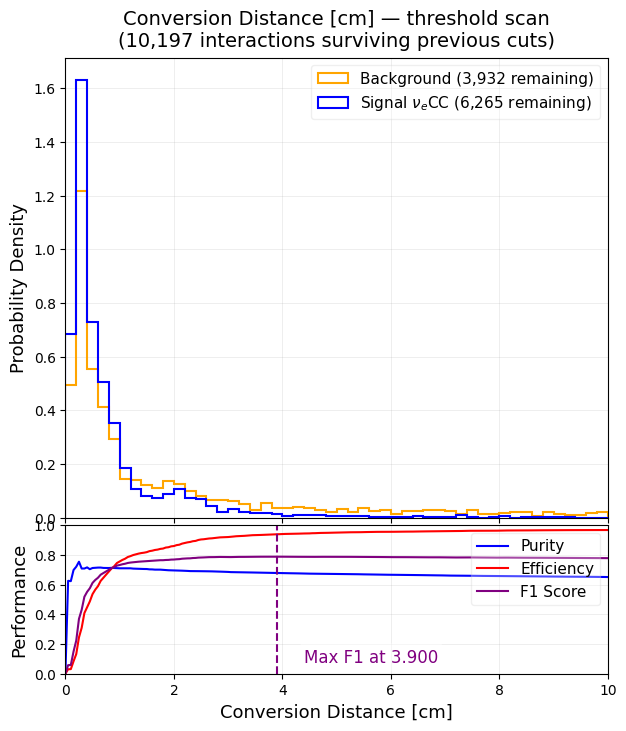


──────────────────────────────────────────────────
  Variable   : vertex_distance
  Remaining  : 10,197 interactions (6265 signal, 3932 bkg)
  Cut dir    : < 3.9000
  Efficiency : 94.0%  (of remaining signal)
  Purity     : 67.9%
  Max F1     : 0.7885
──────────────────────────────────────────────────



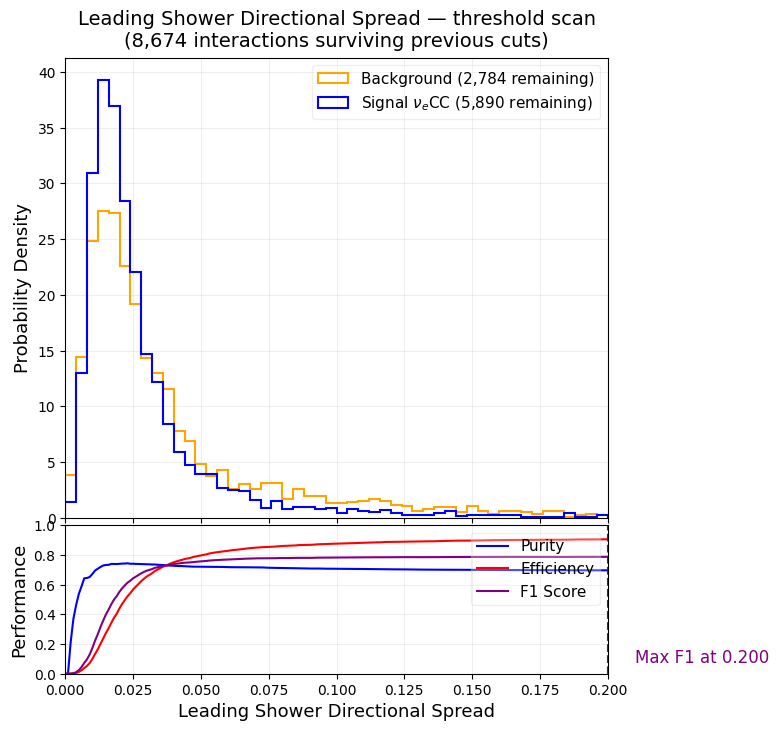


──────────────────────────────────────────────────
  Variable   : directional_spread
  Remaining  : 8,674 interactions (5890 signal, 2784 bkg)
  Cut dir    : < 0.2000
  Efficiency : 90.6%  (of remaining signal)
  Purity     : 69.7%
  Max F1     : 0.7877
──────────────────────────────────────────────────



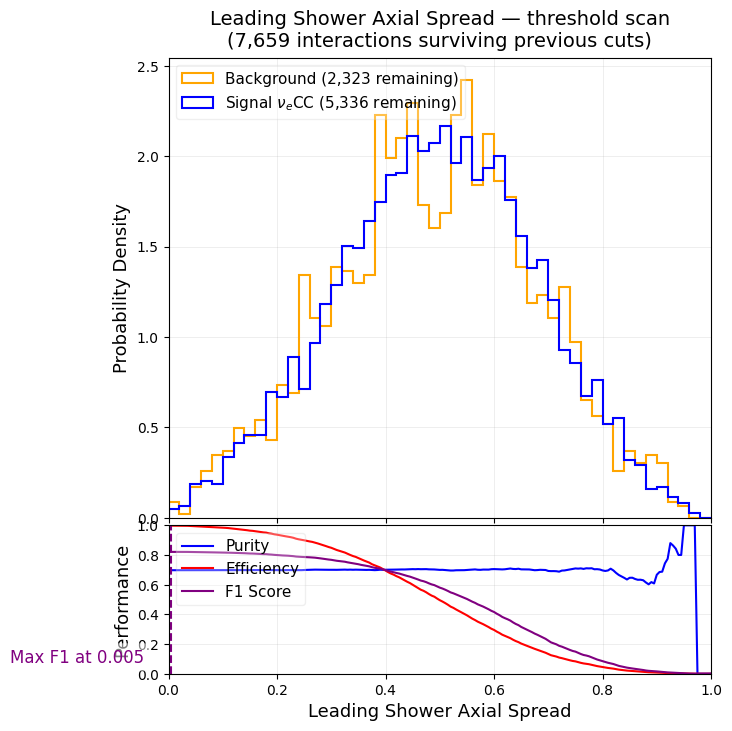


──────────────────────────────────────────────────
  Variable   : axial_spread
  Remaining  : 7,659 interactions (5336 signal, 2323 bkg)
  Cut dir    : > 0.0050
  Efficiency : 99.8%  (of remaining signal)
  Purity     : 69.7%
  Max F1     : 0.8209
──────────────────────────────────────────────────



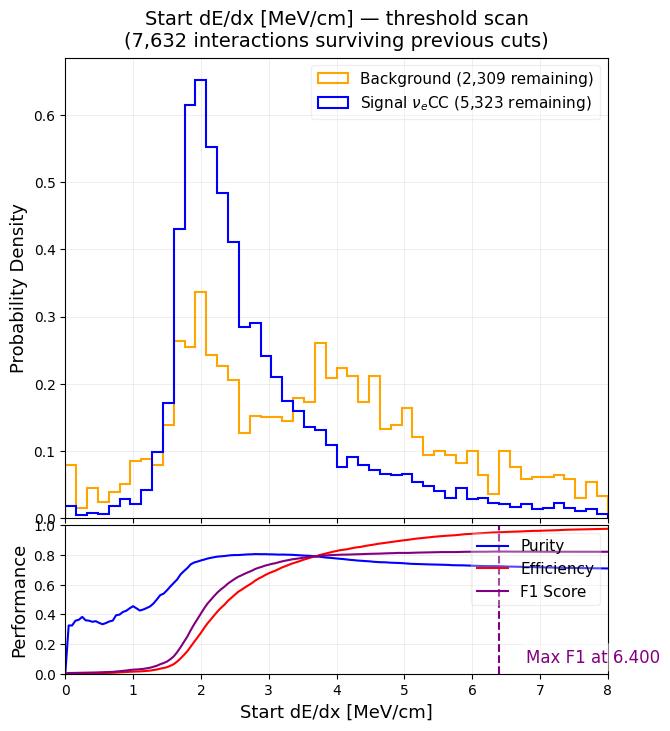


──────────────────────────────────────────────────
  Variable   : start_dedx
  Remaining  : 7,632 interactions (5323 signal, 2309 bkg)
  Cut dir    : < 6.4000
  Efficiency : 95.3%  (of remaining signal)
  Purity     : 72.5%
  Max F1     : 0.8232
──────────────────────────────────────────────────


Final surviving interactions: 7,000

Optimal thresholds (cumulative):
  primary_scores                : 0.9950
  pid_scores                    : 0.9150
  vertex_distance               : 3.9000
  directional_spread            : 0.2000
  axial_spread                  : 0.0050
  start_dedx                    : 6.4000


In [24]:
import nue_helpers as nh

shower_cuts = [
    ("primary_scores",     [0.5, 1.0], "Electron Primary Softmax Score",     [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_primary_score"),
    ("pid_scores",         [0.5, 1.0], "Electron PID Softmax Score",        [0.5, 1.0,  0.005], '>',  'left',  "f1_thrsh_electron_pid_score"),
    ("vertex_distance",    [0.0, 10.], "Conversion Distance [cm]",           [0.0, 10.0, 0.05],  '<',  'right', "f1_thrsh_vertex_distance"),
    ("directional_spread", [0.0, 0.2], "Leading Shower Directional Spread",  [0.0, 0.2,  0.001], '<',  'right', "f1_thrsh_directional_spread"),
    ("axial_spread",       [0.0, 1.0], "Leading Shower Axial Spread",        [0.0, 1.0,  0.005], '>',  'left',  "f1_thrsh_axial_spread"),
    ("start_dedx",         [0.0, 8.0], "Start dE/dx [MeV/cm]",              [0.0, 8.0,  0.05],  '<',  'right', "f1_thrsh_start_dedx"),
]

# opt_thresholds = {}
# for col, bounds, xlabel, trange, cdir, lloc, sname in shower_cuts:
#     opt_t, opt_f1 = nh.threshold_plots(
#         evtdf            = evtdf,
#         cut_flow_result  = cut_flow,
#         cut_stage        = "single_electron",
#         metric_col       = col,
#         bounds           = bounds,
#         xaxis_name       = xlabel,
#         plot_title       = f"{xlabel} — threshold scan",
#         threshold_range  = trange,
#         cut_dir          = cdir,
#         legend_loc       = lloc,
#         truth_categories = truth_cats,
#         save_name        = sname,
#         plot_folder      = PLOT_DIR,
#     )
#     opt_thresholds[col] = opt_t

# print("\nOptimal thresholds summary:")
# for k, v in opt_thresholds.items():
#     print(f"  {k:<30s}: {v:.4f}")

opt_thresholds_cumulative = nh.threshold_plots_cumulative(
    evtdf            = evtdf,
    cut_flow_result  = cut_flow,
    cut_stage        = "single_electron",
    shower_cuts      = shower_cuts,
    truth_categories = truth_cats,
    plot_folder      = PLOT_DIR,
)

print("\nOptimal thresholds (cumulative):")
for k, v in opt_thresholds_cumulative.items():
    print(f"  {k:<30s}: {v:.4f}")

In [27]:
cut_flow_sq = ns.shower_qual_cuts(evtdf)
# efficiency denominator is always n_true_signal (pre-FM/FV, from cell 3)
def _row_stats(stage_idx):
    n_sel_no7 = int((truth_info["truth_cat"].reindex(stage_idx).fillna(7) != 7).sum())
    n_sig     = int(truth_info.loc[
        truth_info["is_true_signal"] & truth_info.index.isin(stage_idx),
        "is_true_signal",
    ].sum())
    pur = n_sig / n_sel_no7     if n_sel_no7       > 0 else float("nan")
    eff = n_sig / n_true_signal if n_true_signal    > 0 else float("nan")
    return len(stage_idx), pur, eff

# ── FM / FV indices from truth_info (not from cut_flow_sq) ───────────────────
fm_idx  = truth_info.index[truth_info["passed_fm"]]
fv_idx  = truth_info.index[truth_info["passed_presel"]]
se_idx  = cut_flow_sq["single_electron"]["inter_index"]

n_i_fm,  pur_fm,  eff_fm  = _row_stats(fm_idx)
n_i_fv,  pur_fv,  eff_fv  = _row_stats(fv_idx)
n_i_se,  pur_se,  eff_se  = _row_stats(se_idx)

# ── Shower-quality stages ─────────────────────────────────────────────────────
sq_names  = ns.CUT_NAMES_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_labels = ns.CUT_LABELS_MORE[ns.CUT_NAMES_MORE.index("single_electron") + 1:]
sq_rows   = {name: _row_stats(cut_flow_sq[name]["inter_index"]) for name in sq_names}

# ── Print ─────────────────────────────────────────────────────────────────────
W = 28
print(f"\n{'Cut':<{W}} {'N inter':>9}  {'Purity':>8}  {'Efficiency':>12}")
print("-" * (W + 36))
print(f"  {'No cut (pre-FM/FV)':<{W-2}} {n_inter_total:>9,}  {'—':>8}  {'100.0%':>12}")
print(f"  {'Flash match':<{W-2}} {n_i_fm:>9,}  {pur_fm*100:>7.1f}%  {eff_fm*100:>11.1f}%")
print(f"  {'In FV':<{W-2}} {n_i_fv:>9,}  {pur_fv*100:>7.1f}%  {eff_fv*100:>11.1f}%")
print(f"  {'Final state topology':<{W-2}} {n_i_se:>9,}  {pur_se*100:>7.1f}%  {eff_se*100:>11.1f}%")
for name, label in zip(sq_names, sq_labels):
    n_i, pur, eff = sq_rows[name]
    print(f"  {label:<{W-2}} {n_i:>9,}  {pur*100:>7.1f}%  {eff*100:>11.1f}%")

Building cut flow:   0%|          | 0/4 [00:00<?, ?it/s]

Applying extra shower-quality cuts:   0%|          | 0/3 [00:00<?, ?it/s]


Cut                            N inter    Purity    Efficiency
----------------------------------------------------------------
  No cut (pre-FM/FV)         57,294,092         —        100.0%
  Flash match                5,129,043      0.2%         86.5%
  In FV                      2,943,724      0.4%         85.6%
  Final state topology          81,970     15.3%         81.2%
  Electron Primary score        42,929     25.2%         68.6%
  Electron PID score            13,208     64.6%         55.2%
  Conversion gap                11,197     70.8%         51.8%


### 5-1. Efficiency/purity stats

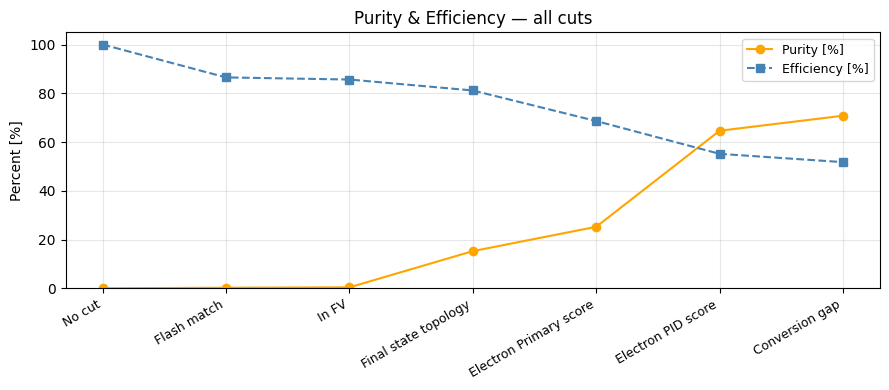

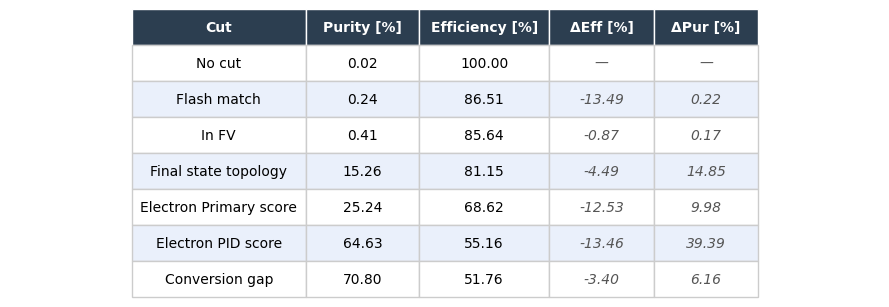

In [28]:
# ── Recompute purs/effs correctly (FM/FV from truth_info, cat7 excluded) ─────
_stage_idx_sq = {
    "precut"          : truth_info.index,
    "valid_flashmatch": truth_info.index[truth_info["passed_fm"]],
    "fiducial"        : truth_info.index[truth_info["passed_presel"]],
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_sq:
        _stage_idx_sq[_name] = cut_flow_sq[_name]["inter_index"]

purs_all, effs_all = [], []
for _name in ns.CUT_NAMES_MORE:
    purs_all.append(_row_stats(_stage_idx_sq[_name])[1])
    effs_all.append(_row_stats(_stage_idx_sq[_name])[2])

# ── Line plot ─────────────────────────────────────────────────────────────────
fig_pe, ax_pe = plt.subplots(figsize=(9, 4))
ax_pe.plot(ns.CUT_LABELS_MORE, [p * 100 for p in purs_all], "o-",  color="orange",    label="Purity [%]")
ax_pe.plot(ns.CUT_LABELS_MORE, [e * 100 for e in effs_all], "s--", color="steelblue", label="Efficiency [%]")
ax_pe.set_ylim(0, 105)
ax_pe.set_xticks(range(len(ns.CUT_LABELS_MORE)))
ax_pe.set_xticklabels(ns.CUT_LABELS_MORE, rotation=30, ha="right", fontsize=9)
ax_pe.set_ylabel("Percent [%]")
ax_pe.set_title("Purity & Efficiency — all cuts")
ax_pe.legend(fontsize=9)
ax_pe.grid(alpha=0.3)
plt.tight_layout()
plt.show()
nh.save_plot("cutflow_pur_eff_final", fig=fig_pe, folder_name=PLOT_DIR)

# ── Numeric table ─────────────────────────────────────────────────────────────
fig_tab, ax_tab = plt.subplots(figsize=(9, 3.2))
nh.create_purity_efficiency_table(purs_all, effs_all, ns.CUT_LABELS_MORE, ax_tab)
fig_tab.tight_layout()
plt.show()
nh.save_plot("pur_eff_table_all_final", fig=fig_tab, folder_name=PLOT_DIR)

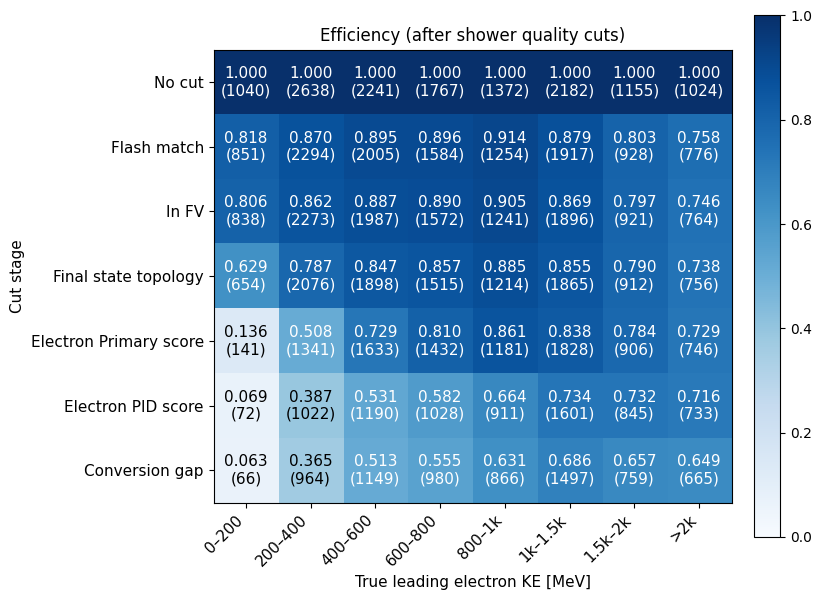

In [29]:
# =============================================================================
# Efficiency matrix — all cuts × true KE bins
# FM/FV now use truth_info flags via _stage_idx_sq (same fix as confusion matrix)
# =============================================================================
ke_bins_c = np.array([0, 200, 400, 600, 800, 1000, 1500, 2000, np.inf])
ke_bin_labels = [
    "0–200", "200–400", "400–600", "600–800",
    "800–1k", "1k–1.5k", "1.5k–2k", ">2k",
]
n_bins = len(ke_bins_c) - 1
n_cuts = len(ns.CUT_NAMES_MORE)

ke_vals_sq  = truth_info["true_leading_e_ke"].fillna(-999).values
sig_vals_sq = truth_info["is_true_signal"].values

stage_sel_sq = {
    cut_name: truth_info.index.isin(_stage_idx_sq[cut_name])
    for cut_name in ns.CUT_NAMES_MORE
}

eff_matrix   = np.zeros((n_bins, n_cuts))
count_matrix = np.zeros((n_bins, n_cuts))

for ci, cut_name in enumerate(ns.CUT_NAMES_MORE):
    reco_sel = stage_sel_sq[cut_name]
    for i, (lo, hi) in enumerate(zip(ke_bins_c[:-1], ke_bins_c[1:])):
        in_bin       = (ke_vals_sq >= lo) & (ke_vals_sq < hi)
        sig_total    = (in_bin & sig_vals_sq).sum()
        sig_selected = (in_bin & sig_vals_sq & reco_sel).sum()
        eff_matrix[i, ci]   = sig_selected / sig_total if sig_total > 0 else 0
        count_matrix[i, ci] = sig_selected

fig, ax = nh.plot_matrix_binned(
    eff_matrix, count_matrix,
    bin_values       = np.arange(n_bins),
    bin_labels       = ke_bin_labels,
    cut_labels       = ns.CUT_LABELS_MORE,
    remove_dummy_col = False,
    xlabel           = "True leading electron KE [MeV]",
    title            = "Efficiency (after shower quality cuts)",
    cmap             = "Blues",
)
fig.tight_layout()
nh.save_plot("eff_matrix_true_ke_final", fig=fig, folder_name=PLOT_DIR)

In [31]:
import gc
SEL_QUAL_FILE = os.path.join(DF_OUT_DIR, "selected_nuecc_qual.df")

_stage_idx_qual = {
    "precut"          : presel_inter,
    "valid_flashmatch": truth_info.index[truth_info["passed_fm"]],
    "fiducial"        : truth_info.index[truth_info["passed_presel"]],
}
for _name in ns.CUT_NAMES_MORE:
    if _name not in _stage_idx_qual:
        _stage_idx_qual[_name] = cut_flow_sq[_name]["inter_index"]

sel_qual = nh.build_and_save_selection(
    path             = SEL_QUAL_FILE,
    presel_inter     = presel_inter,
    truth_cat_presel = truth_cat_presel,
    reco_ke          = ns.leading_electron_ke(evtdf),
    reco_cos         = ns.leading_electron_costheta(evtdf),
    true_ke          = ns.true_leading_electron_ke(evtdf),
    true_cos         = ns.true_leading_electron_costheta(evtdf),
    stage_idx_dict   = _stage_idx_qual,
    cut_names        = ns.CUT_NAMES_MORE,
    pot_scale        = pot_scale,
)

del evtdf
gc.collect()
print(f"evtdf freed. sel_qual shape: {sel_qual.shape}")


NameError: name 'evtdf' is not defined

### 5-2. Histograms

NameError: name 'DISPLAY_CATS' is not defined

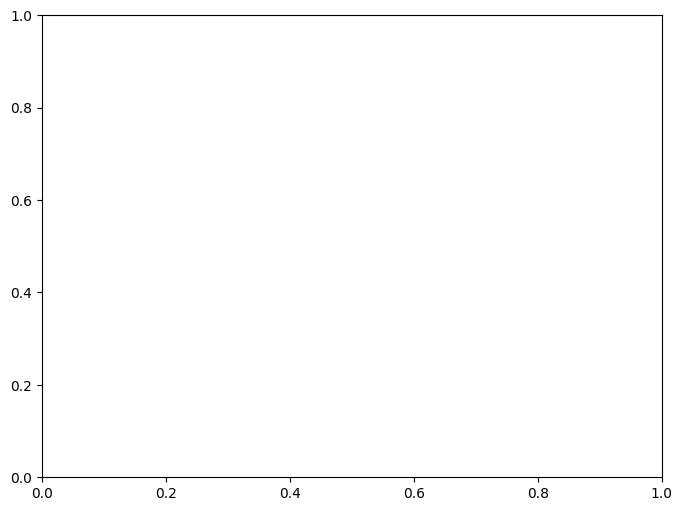

In [32]:
# ── Final stacked histograms from sel_qual ────────────────────────────────────
final_col = f"sel_{ns.CUT_NAMES_MORE[-1]}"

def _qual_cat(col, cat):
    mask = sel_qual[final_col] & (sel_qual["truth_cat"] == cat)
    # require both ke and costheta valid for consistent denominators
    mask = mask & sel_qual["reco_ke"].notna() & sel_qual["reco_costheta"].notna()
    return sel_qual.loc[mask, col].values

fig_ke2, ax_ke2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_ke", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors,
    bins=np.concatenate([np.linspace(0, 2000, 41)]),
    weights=pot_scale, xlabel="Reco leading-electron KE [MeV]",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_ke2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_ke_final", fig=fig_ke2, folder_name=PLOT_DIR)

fig_cos2, ax_cos2 = plt.subplots(figsize=(8, 6))
nh.plot_stacked_hist(
    series_list=[_qual_cat("reco_costheta", c) for c in DISPLAY_CATS],
    labels=_labels, colors=_colors, bins=np.linspace(-1, 1, 41),
    weights=pot_scale, xlabel=r"Reco leading-electron $\cos\theta$",
    title=fr"{TITLE} (After shower quality cuts)",
    pot_label=fr"$6.6\times10^{{20}}$ POT",
    ax=ax_cos2, invert_stack_order=True,
)
plt.show()
nh.save_plot("hist_reco_costheta_final", fig=fig_cos2, folder_name=PLOT_DIR)

In [23]:
pause

NameError: name 'pause' is not defined